In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import sctk as sk
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/SGN_analysis/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_obj_utils.py:8: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc_warn = sc.logging.warn if sc.__version__.startswith("1.4") else sc.logging.warning
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc_warn = sc.logging.warn if sc.__version__.startswith("1.4") else sc.logging.warning
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_paga.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):
G:\Miniconda3\envs\omicverse\lib\site-packages\sctk\_plot.py:18: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [2]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


In [3]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata_v2.csv',index_col=0)
meta

,sample_id,sample_id2,donor,gw,gender,10xKit,sequencing,dataset
sample,,,,,,,,
9.5gw,gw9,gw9,not_provided_1,9,female,SC3,snRNA-seq,public
11.2gw,gw11,gw11,not_provided_2,11,male,SC3,snRNA-seq,public
14+3gw,gw14,gw14,F20240701,14,male,SC3,snRNA-seq,in-house
15gw,gw15,gw15,not_provided_3,15,female,SC3,scRNA-seq,public
16+4gw,gw16,gw16,F20241018,16,male,SC3,snRNA-seq,in-house
17+2gw,gw17_1,gw17_1,F20220807,17,male,SC3,snRNA-seq,in-house
17+3gw,gw17_2,gw17_2,F20240928,17,female,SC3,snRNA-seq,in-house
17gw,gw17_3,gw17_3,not_provided_4,17,male,SC3,scRNA-seq,public
18+3gw,gw18,gw18,F20220806,18,male,SC3,snRNA-seq,in-house


In [4]:
adata_positive_early_sgn_hm=sc.read('human_sgn_harmony_integration_early_sgn.h5ad')

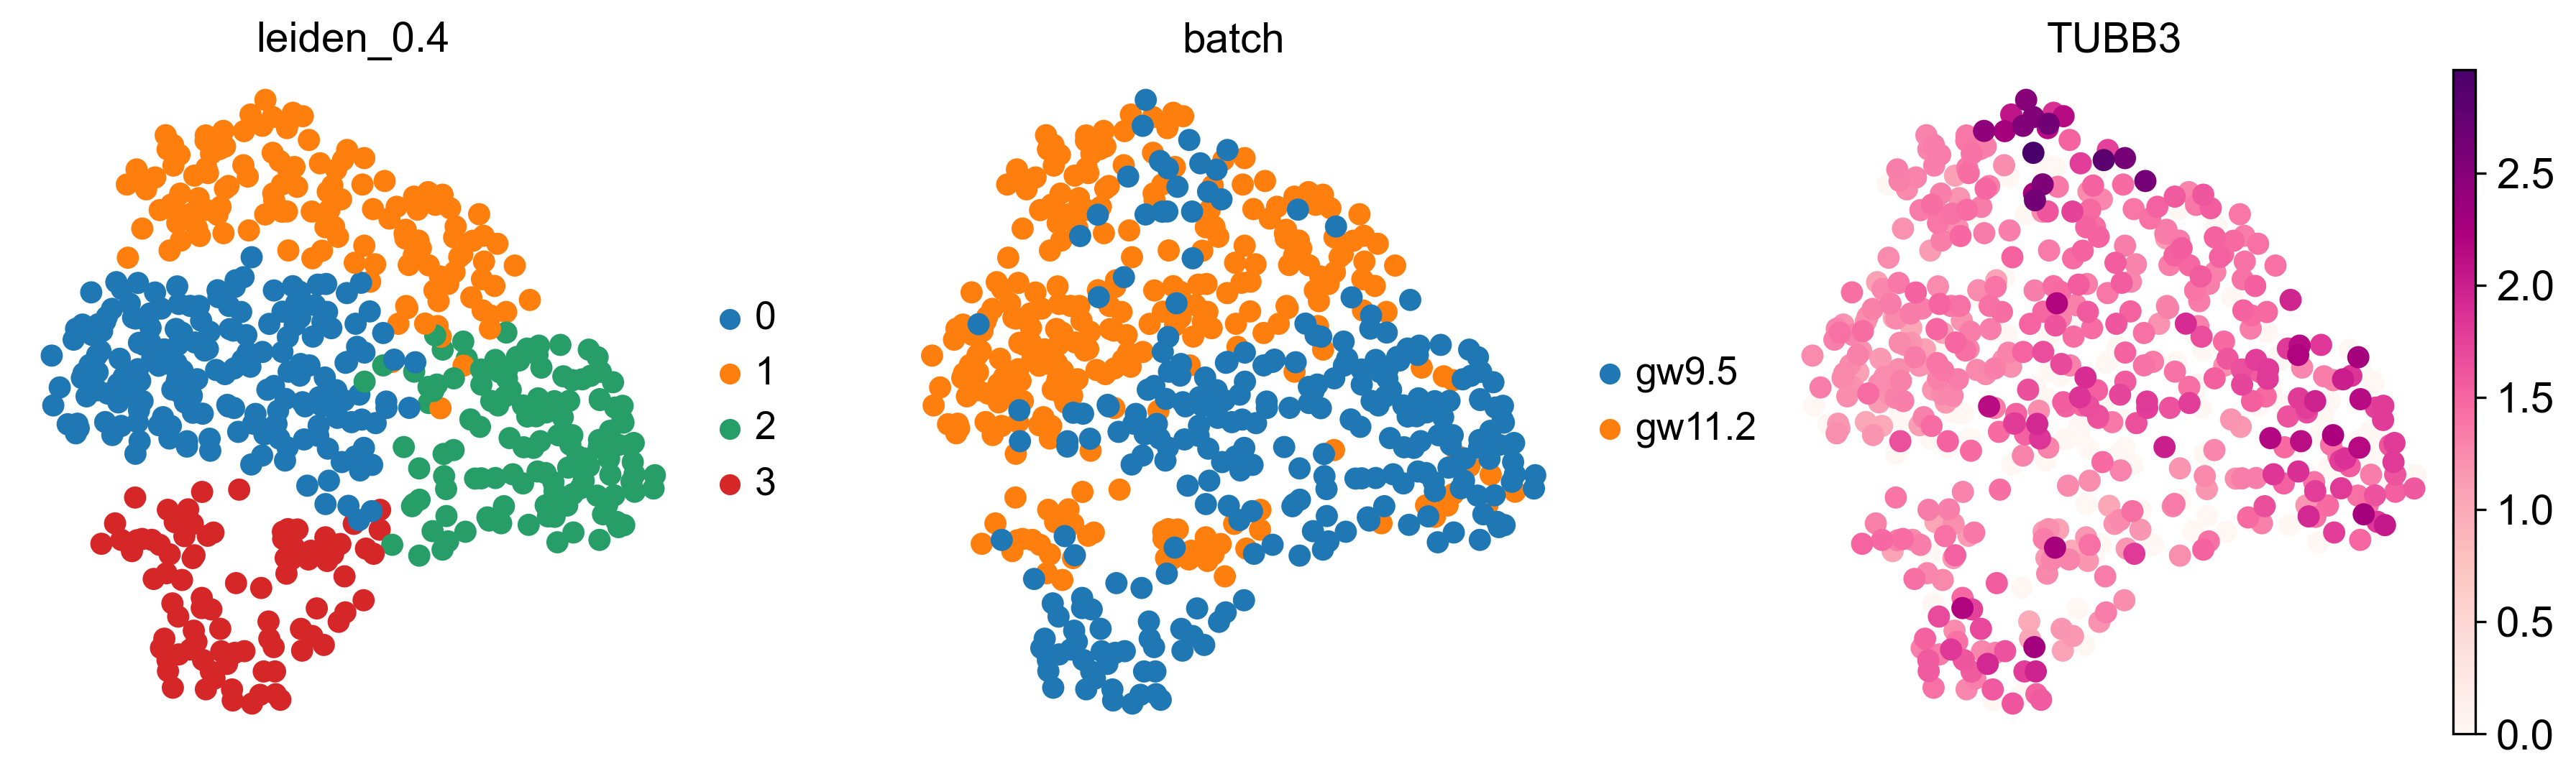

In [5]:
# 可视化整合前后的 UMAP
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_positive_early_sgn_hm, color=['leiden_0.4','batch','TUBB3',
                                               
  
                                             ],ncols=3,)

In [6]:
cluster_annotation = {
 '2': 'NEUROD1+_early_sgn',
     '1': 'IGFBP2+_intermediate_sgn',
     '0': 'LYPD1+_intermediate_sgn',
     '3': 'RUNX1+_intermediate_sgn',
     

}
adata_positive_early_sgn_hm.obs['cell_type_final'] = adata_positive_early_sgn_hm.obs['leiden_0.4'].map(cluster_annotation).astype('category')

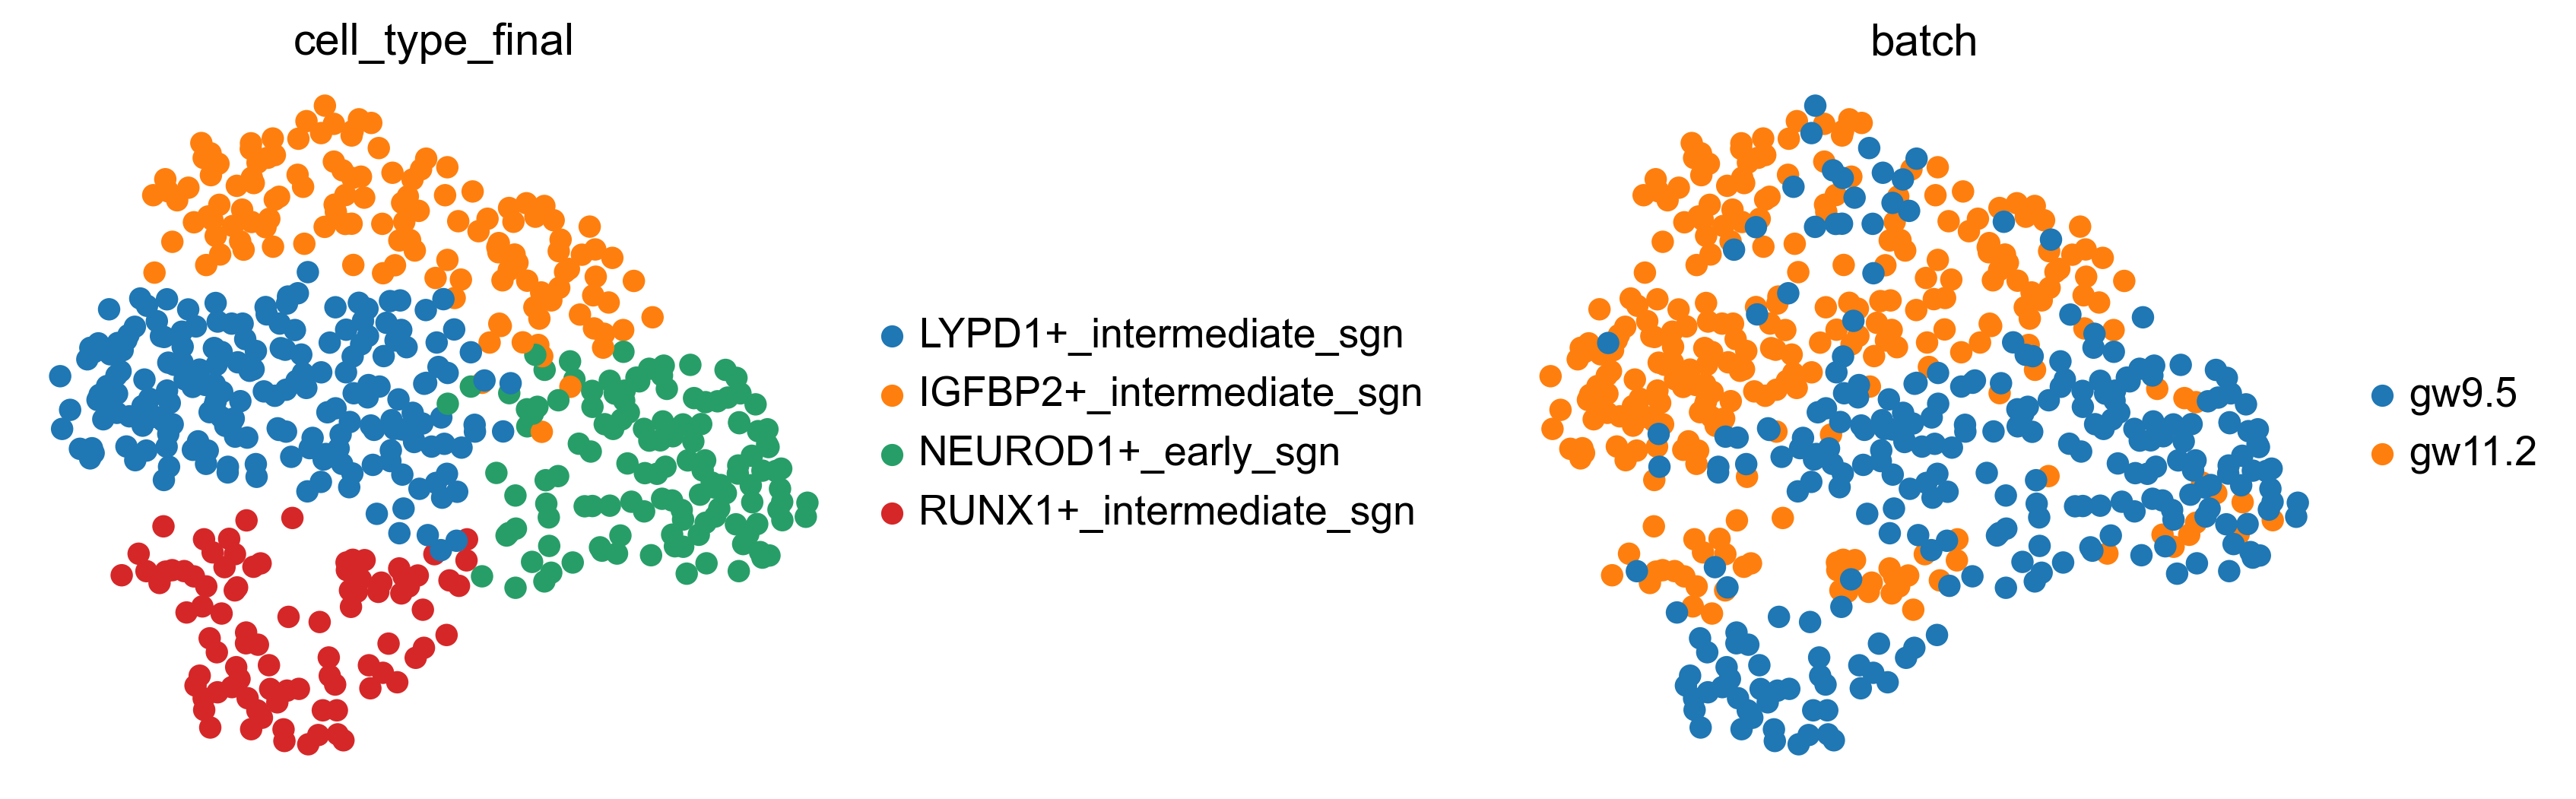

In [7]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_positive_early_sgn_hm, color=['cell_type_final','batch',],size=200,
           wspace=0.65,ncols=2,color_map = "RdPu",)

In [48]:
%run _markers_v2.py

In [49]:
mkst = calc_marker_stats(adata_positive_early_sgn_hm, 'cell_type_final',use_rep=False,)

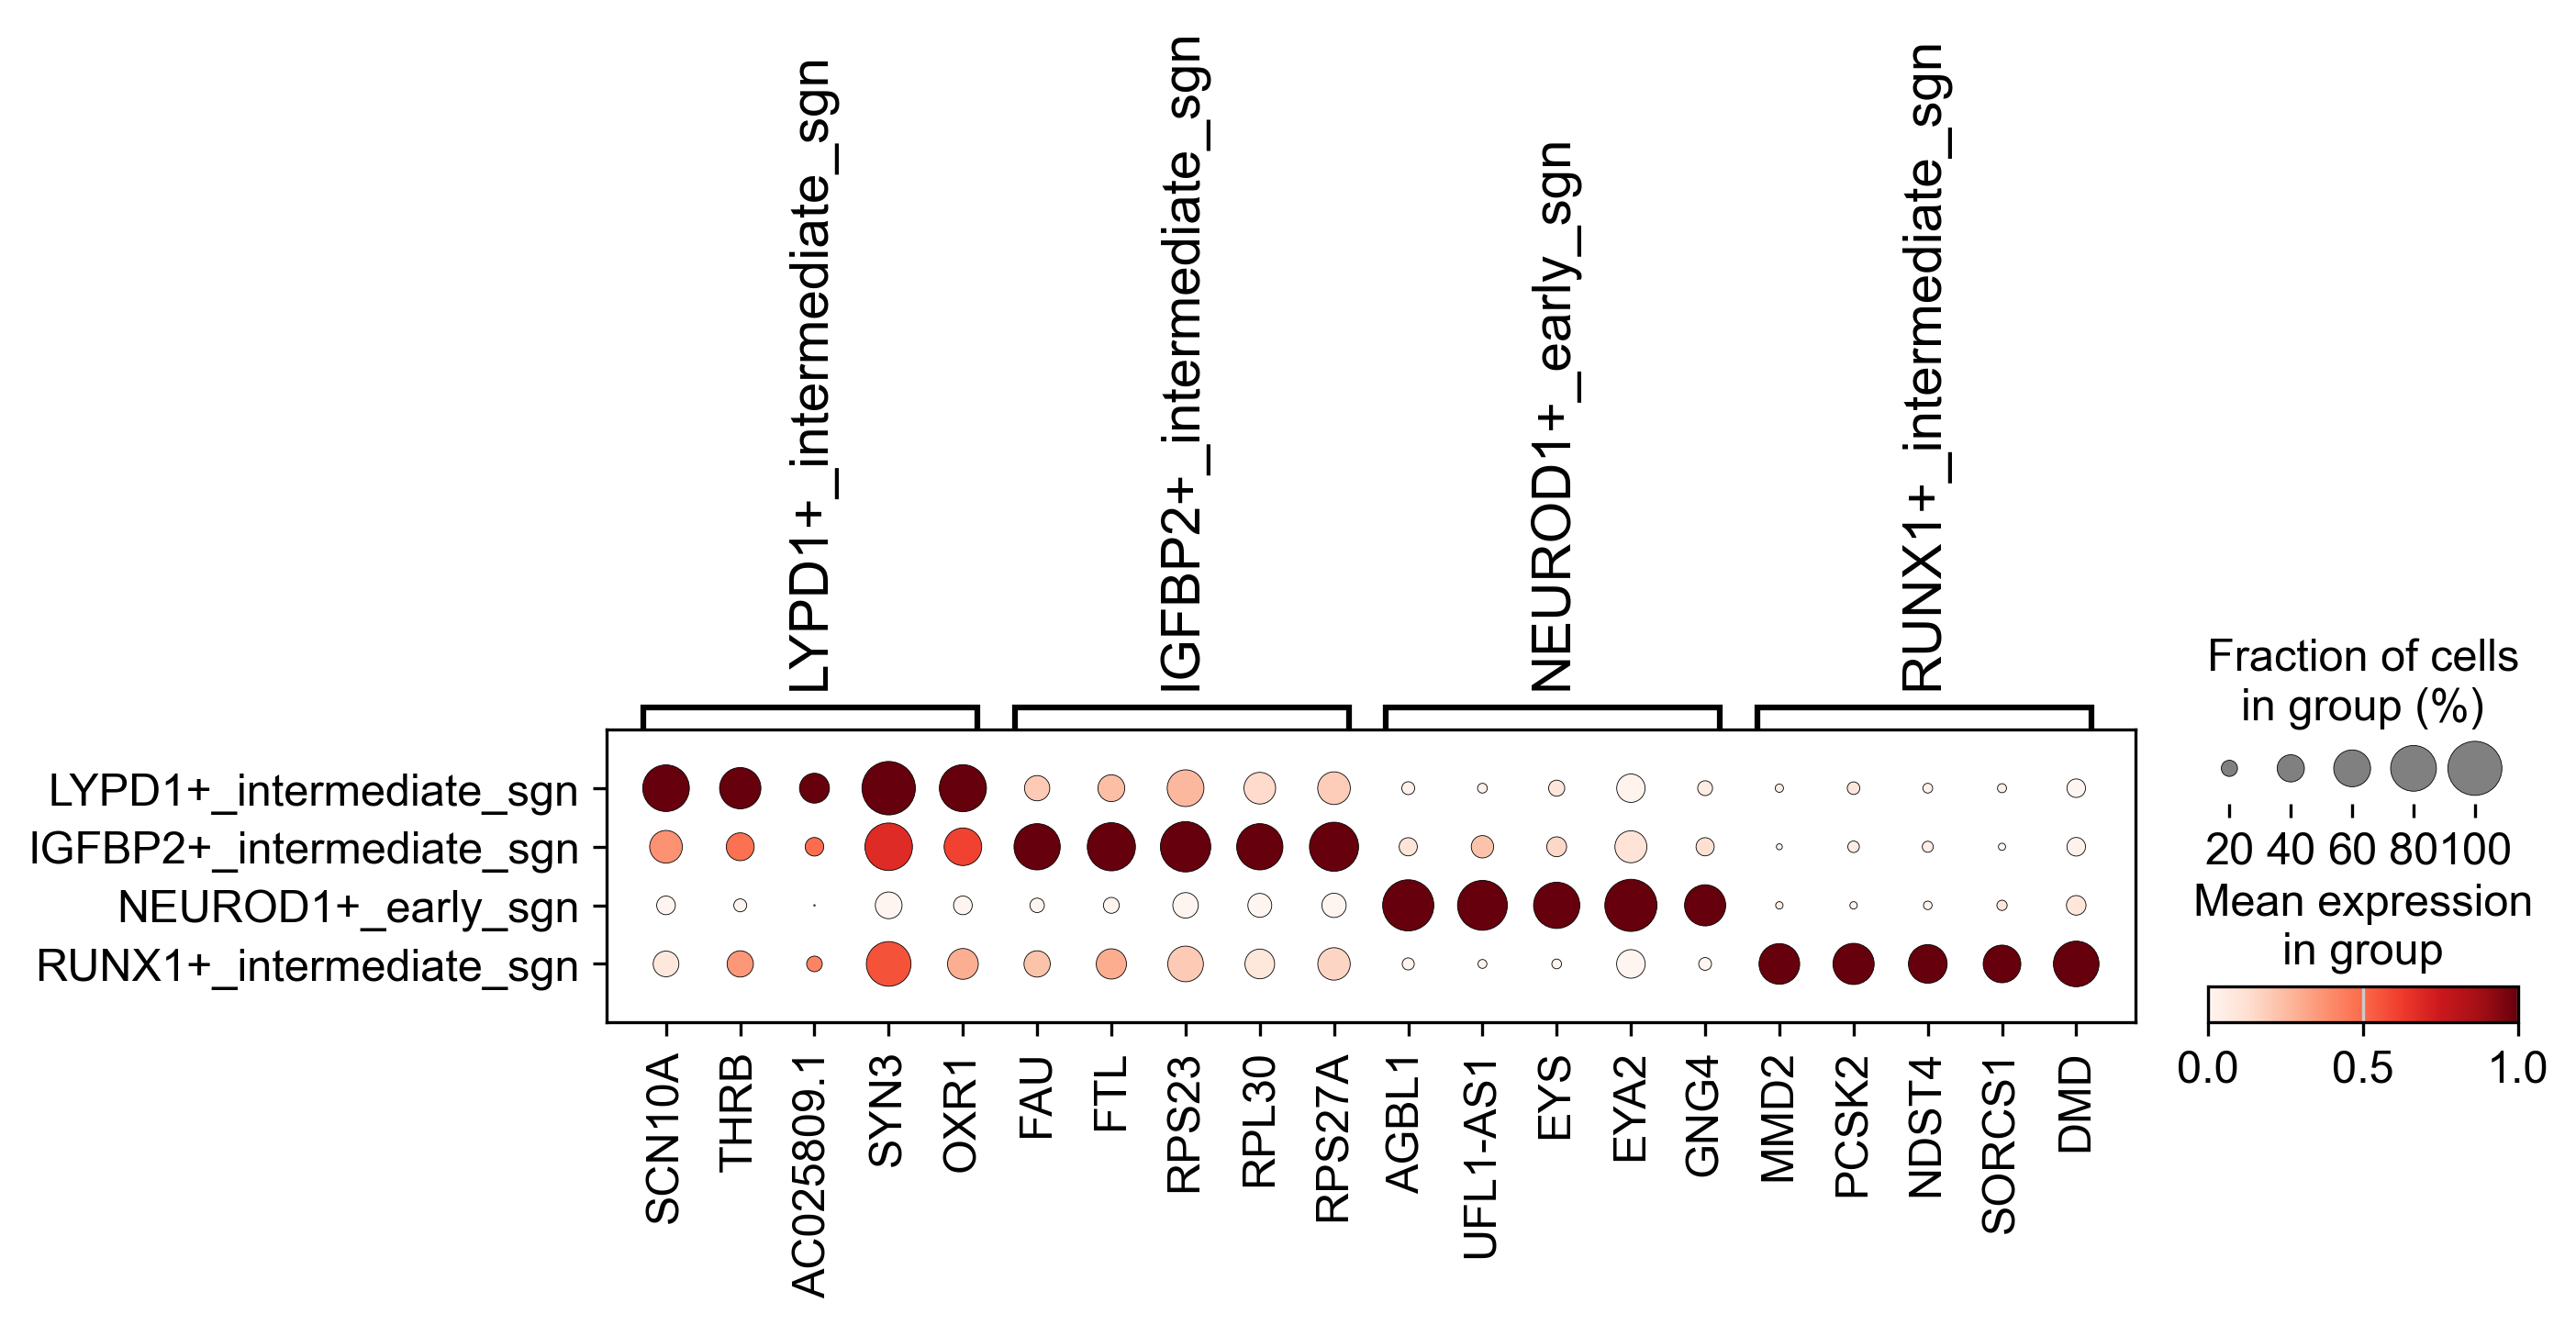

In [58]:
mks = filter_marker_stats(mkst, max_next_frac=0.5, min_mean_diff=0.1, how='or')
plot_markers(adata_positive_early_sgn_hm, 'cell_type_final', mks, standard_scale='var', save='dotplot_early_sgn_top5.pdf')

In [59]:
pd.DataFrame(mks).to_csv('human_early_sgn_markers.csv')

In [21]:
adata_positive_gradual_sgn_hm=sc.read('human_sgn_harmony_integration_gradual_sgn_revision2.h5ad')

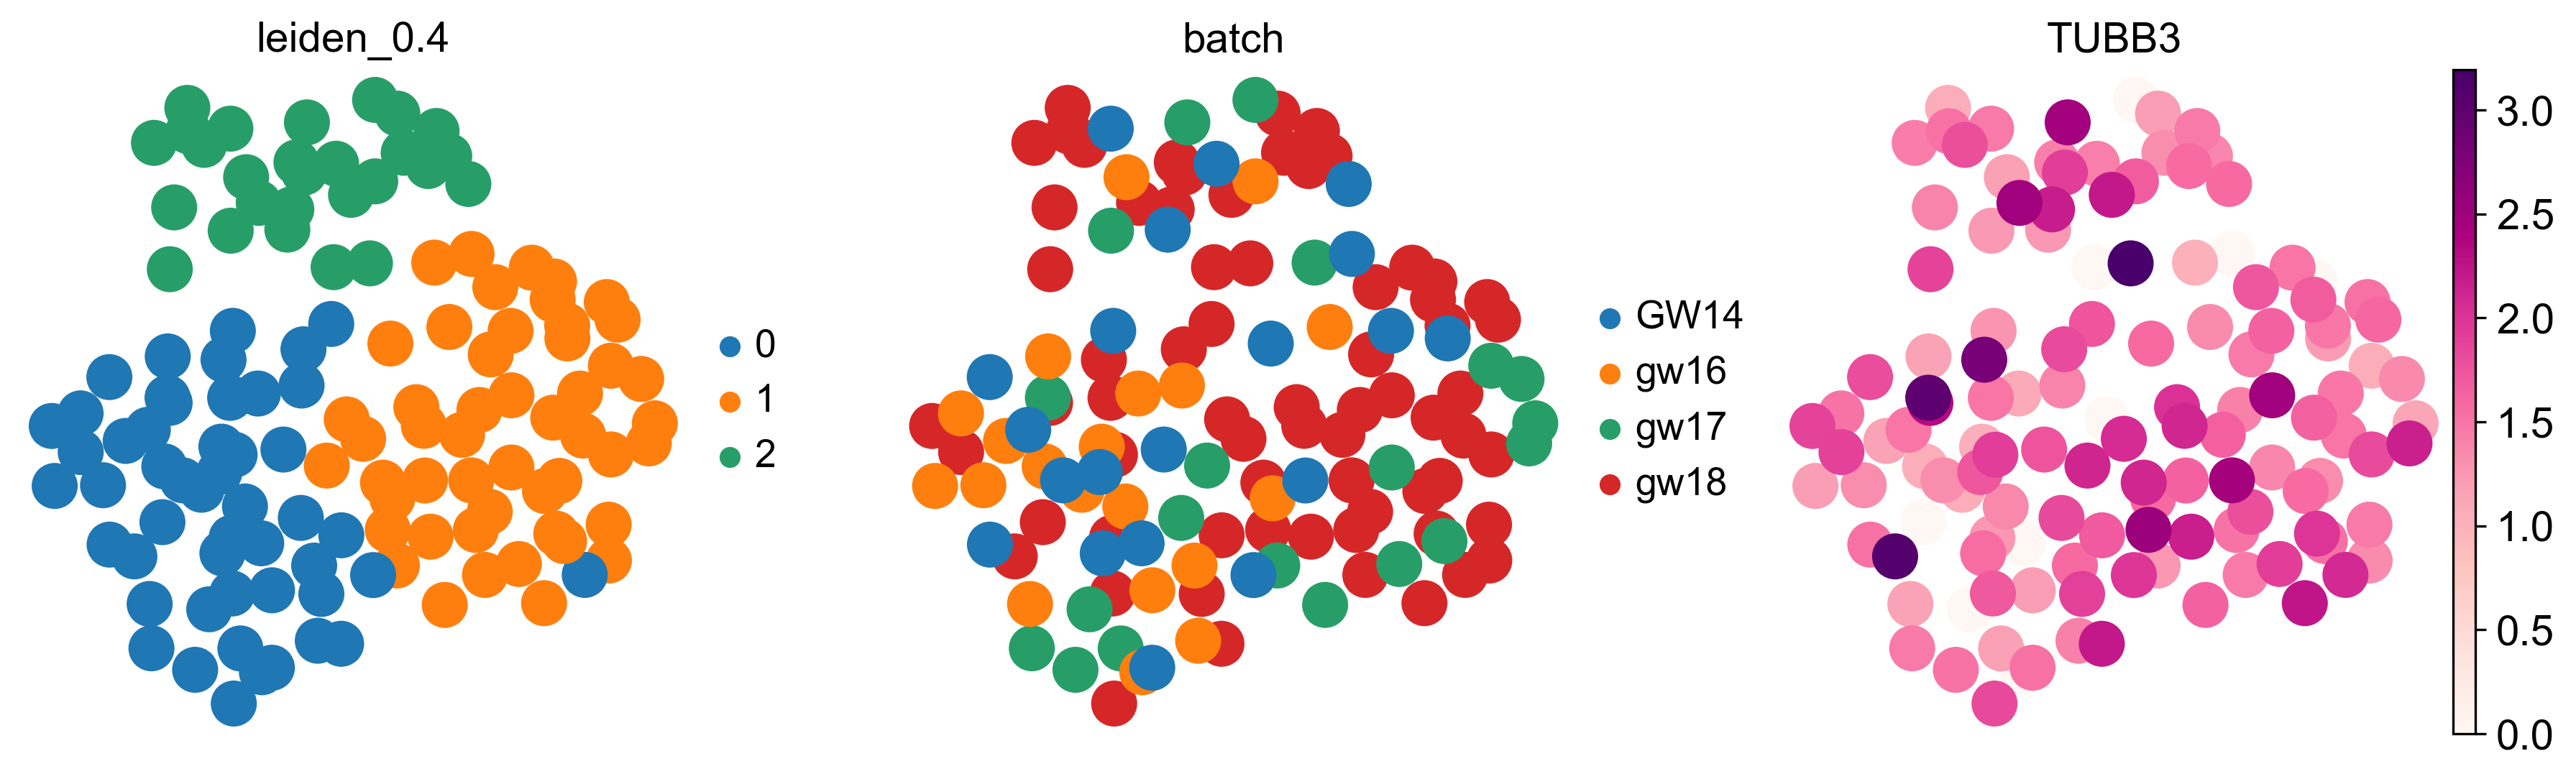

In [22]:
# 可视化整合前后的 UMAP
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_positive_gradual_sgn_hm, color=['leiden_0.4','batch','TUBB3',
                                              
  
  
                                             ],ncols=3,)

In [23]:
# cluster 2 name as IGFBP2+_intermediate_sgn
# clusetr 1 name as LYPD1+_immature_sgn
# cluster 0 name as CLU+_immature_sgn
cluster_annotation = {
 '2': 'IGFBP2+_intermediate_sgn',
     '1': 'LYPD1+_immature_sgn',
     '0': 'CLU+_immature_sgn',
          

}
adata_positive_gradual_sgn_hm.obs['cell_type_final'] = adata_positive_gradual_sgn_hm.obs['leiden_0.4'].map(cluster_annotation).astype('category')

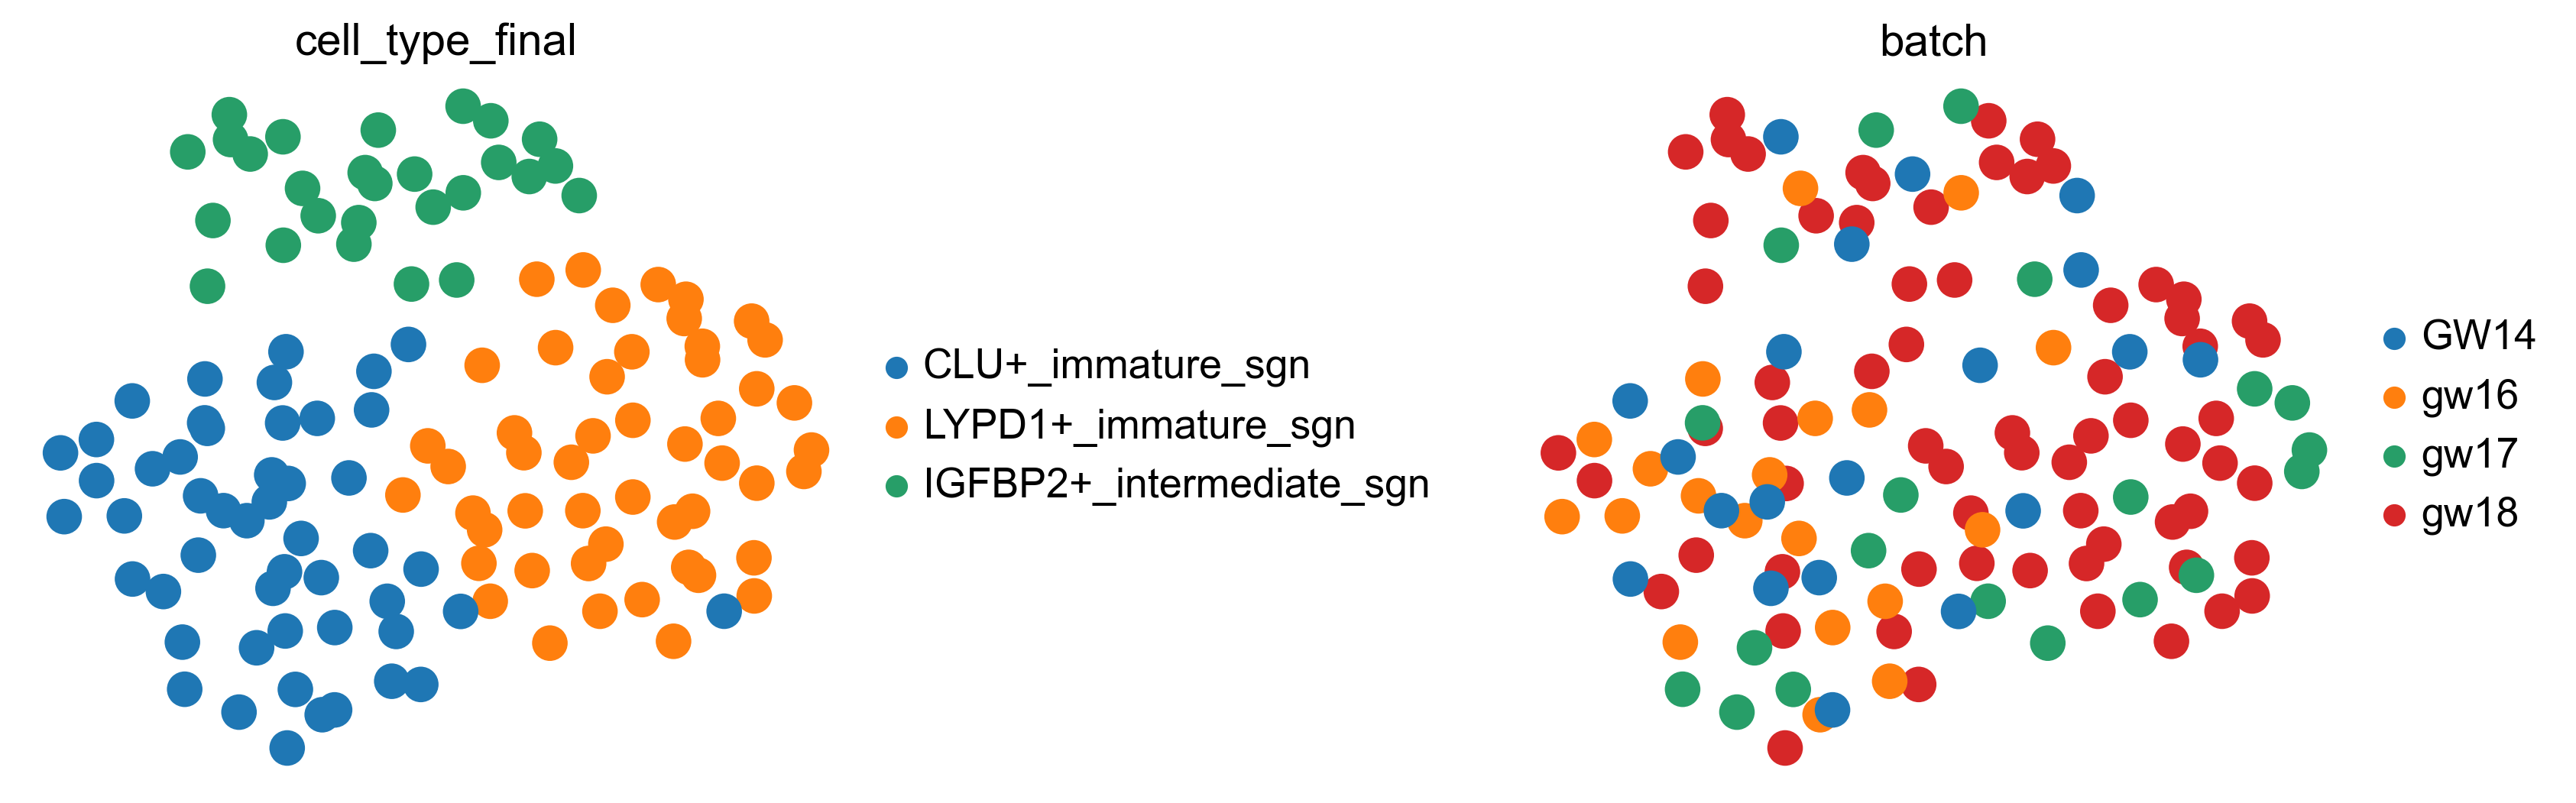

In [24]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.umap(adata_positive_gradual_sgn_hm, color=['cell_type_final','batch',],size=500,
           wspace=0.65,ncols=2,color_map = "RdPu",)

In [60]:
mkst_gradual = calc_marker_stats(adata_positive_gradual_sgn_hm, 'cell_type_final',use_rep=False,)

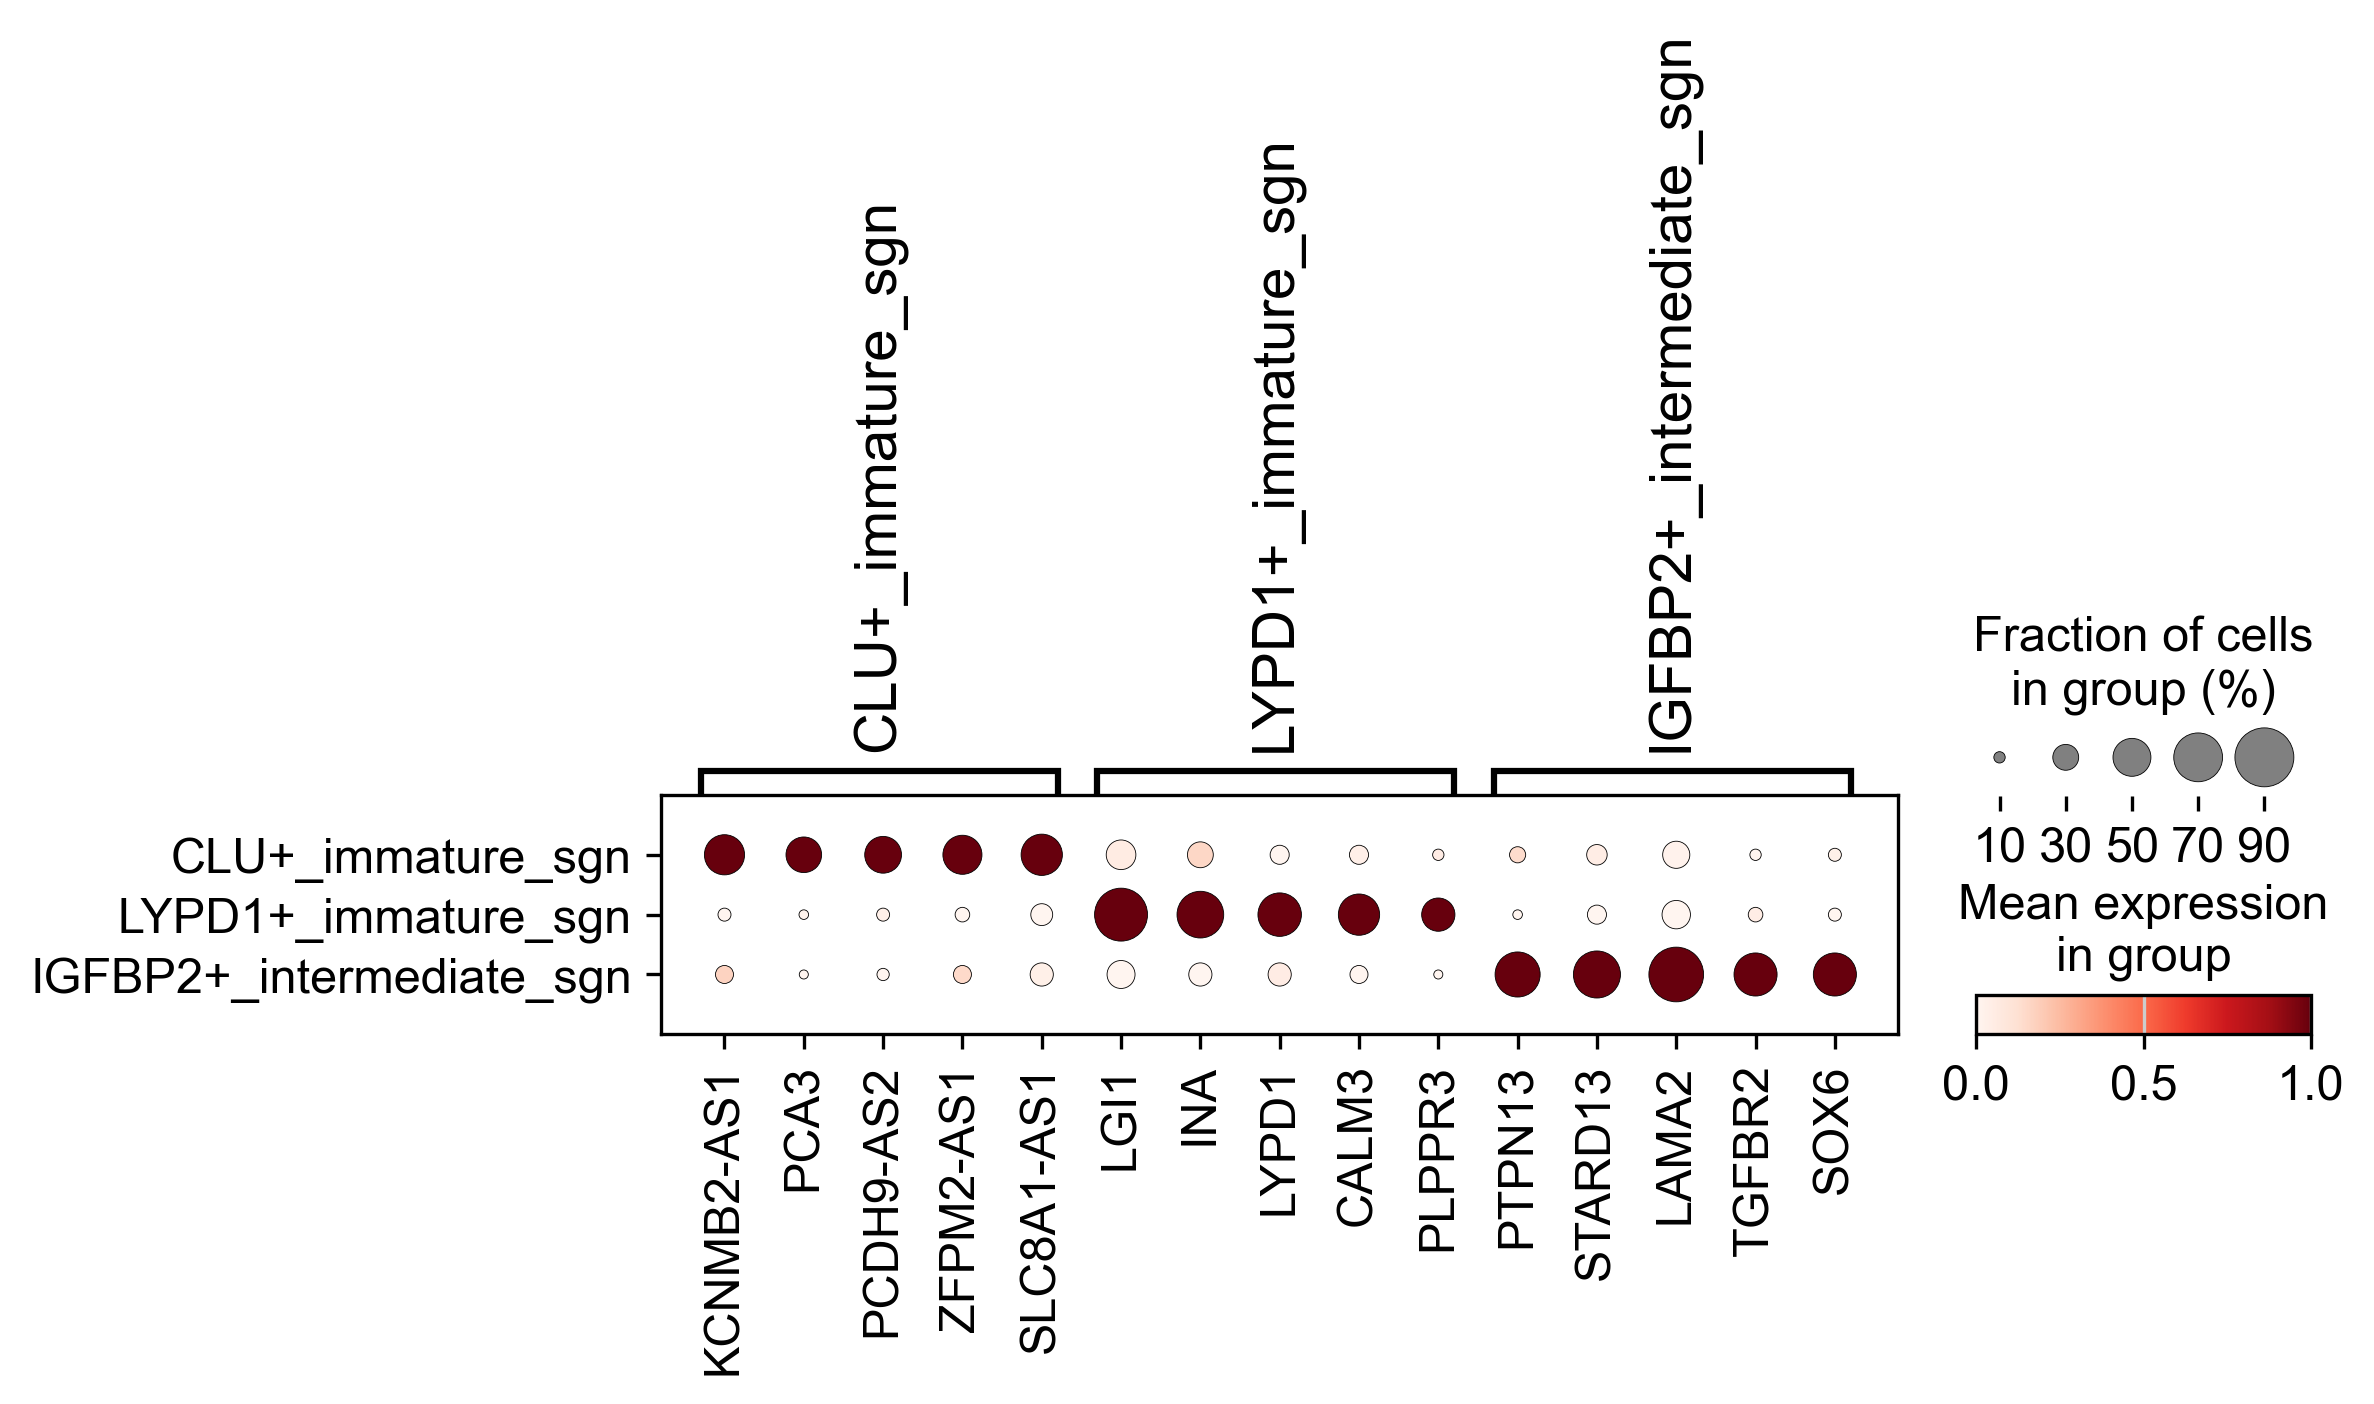

In [63]:
mks_gradual = filter_marker_stats(mkst_gradual, max_next_frac=0.5, min_mean_diff=0.1, how='or')
plot_markers(adata_positive_gradual_sgn_hm, 'cell_type_final', mks_gradual, standard_scale='var', save='dotplot_gradual_sgn_top5.pdf')

In [65]:
pd.DataFrame(mks_gradual).to_csv('human_gradual_sgn_markers.csv')

In [28]:
adata_positive_final_sgn_hm=sc.read('human_sgn_harmony_integration_final_sgn_revision2.h5ad')

In [29]:
cluster_annotation = {
 '0': 'NEFH+/RUNX1+/LYPD1+_mature_sgn',
     '1': 'NEFH+_mature_sgnn',
     '2': 'RUNX1+/LYPD1+_mature_sg',
          

}
adata_positive_final_sgn_hm.obs['cell_type_final'] = adata_positive_final_sgn_hm.obs['leiden_0.4'].map(cluster_annotation).astype('category')

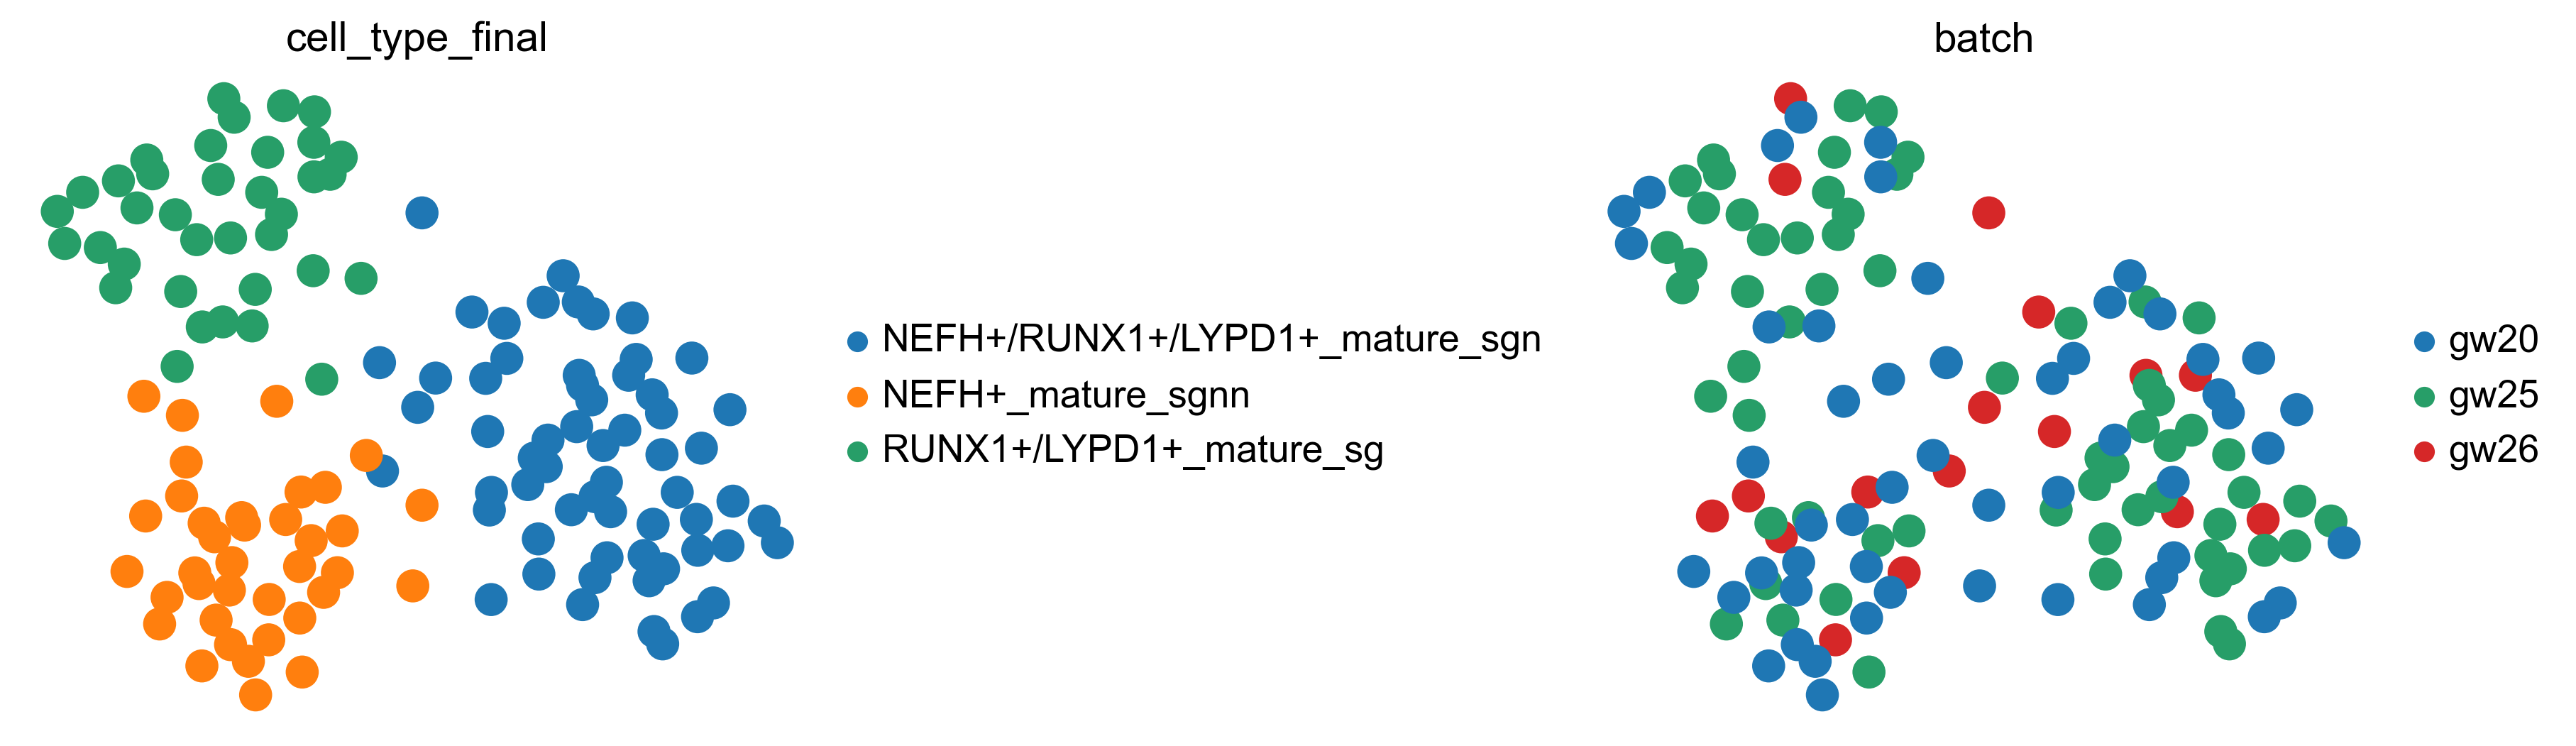

In [31]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
# 使用整合后的嵌入进行 UMAP 降维
sc.pl.umap(adata_positive_final_sgn_hm, color=['cell_type_final','batch',],size=500,
           wspace=0.8,ncols=2,color_map = "RdPu",)

In [66]:
mkst_final = calc_marker_stats(adata_positive_final_sgn_hm, 'cell_type_final',use_rep=False,)

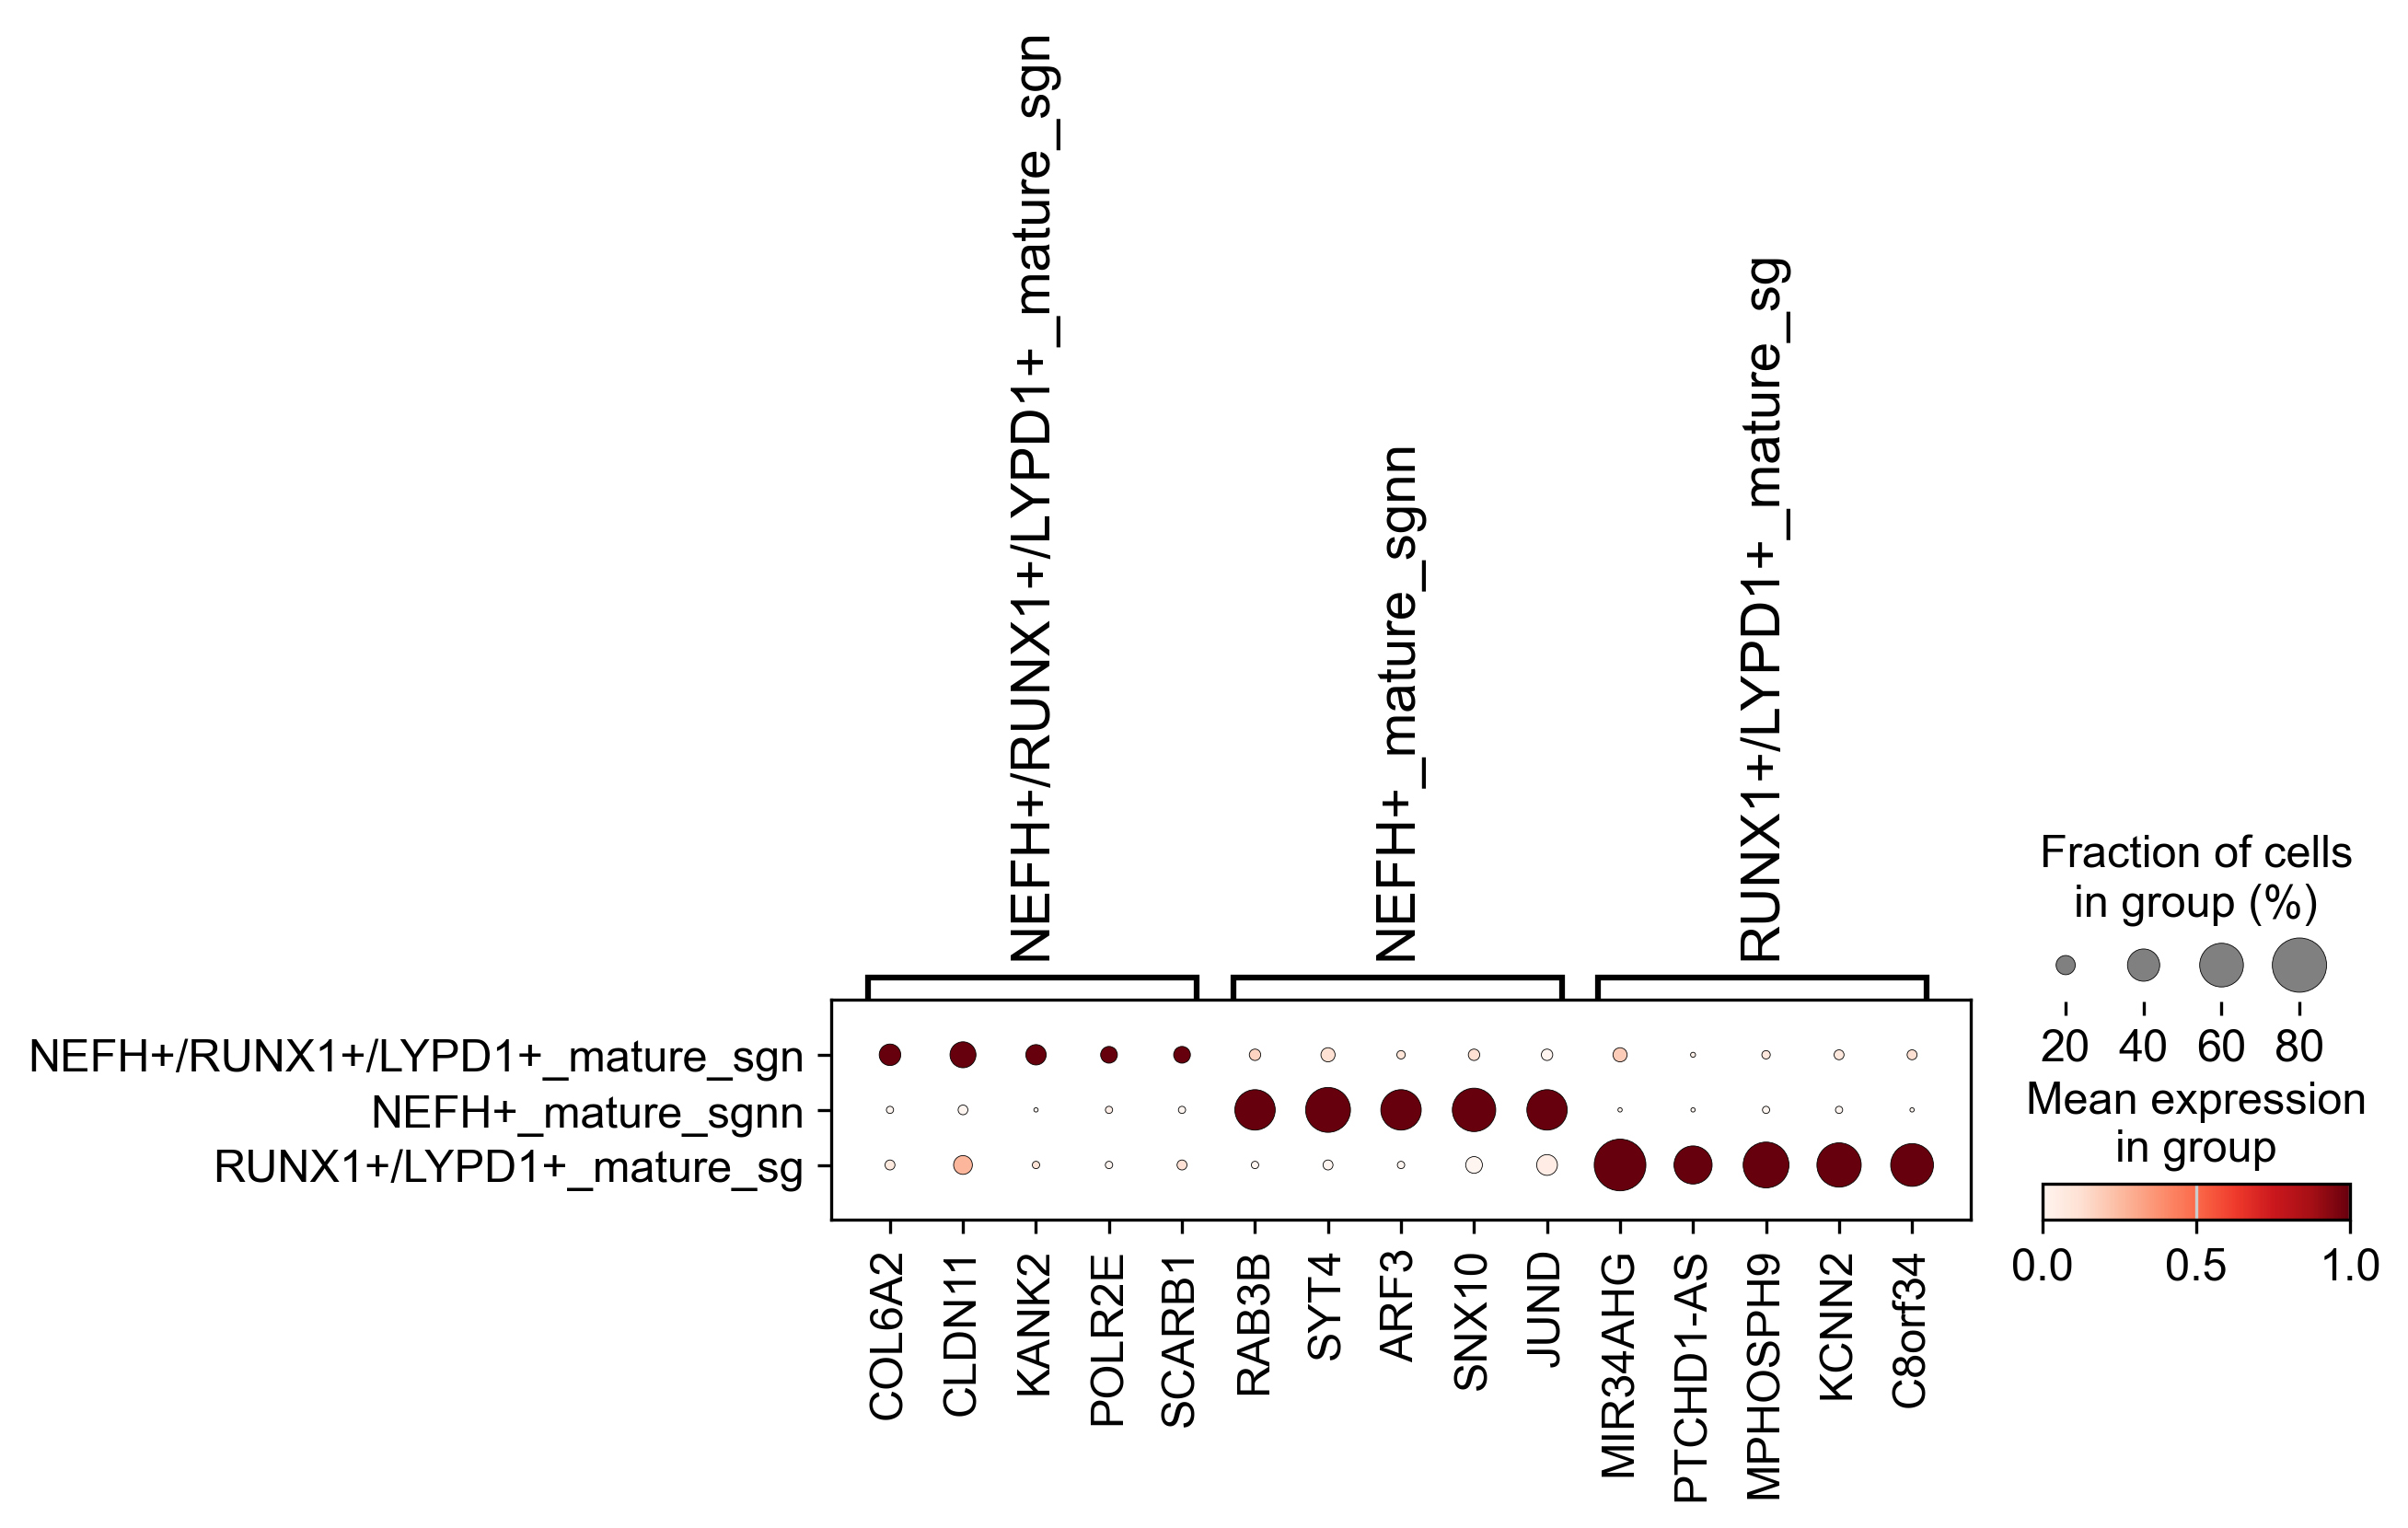

In [86]:
mks_final = filter_marker_stats(mkst_final, max_next_frac=0.1, min_mean_diff=0.01, how='or')
plot_markers(adata_positive_final_sgn_hm, 'cell_type_final', mks_final, standard_scale='var', save='dotplot_final_sgn_top5.pdf')

In [101]:
sc.pp.normalize_total(adata_positive_final_sgn_hm, target_sum=1e4)
sc.pp.log1p(adata_positive_final_sgn_hm)

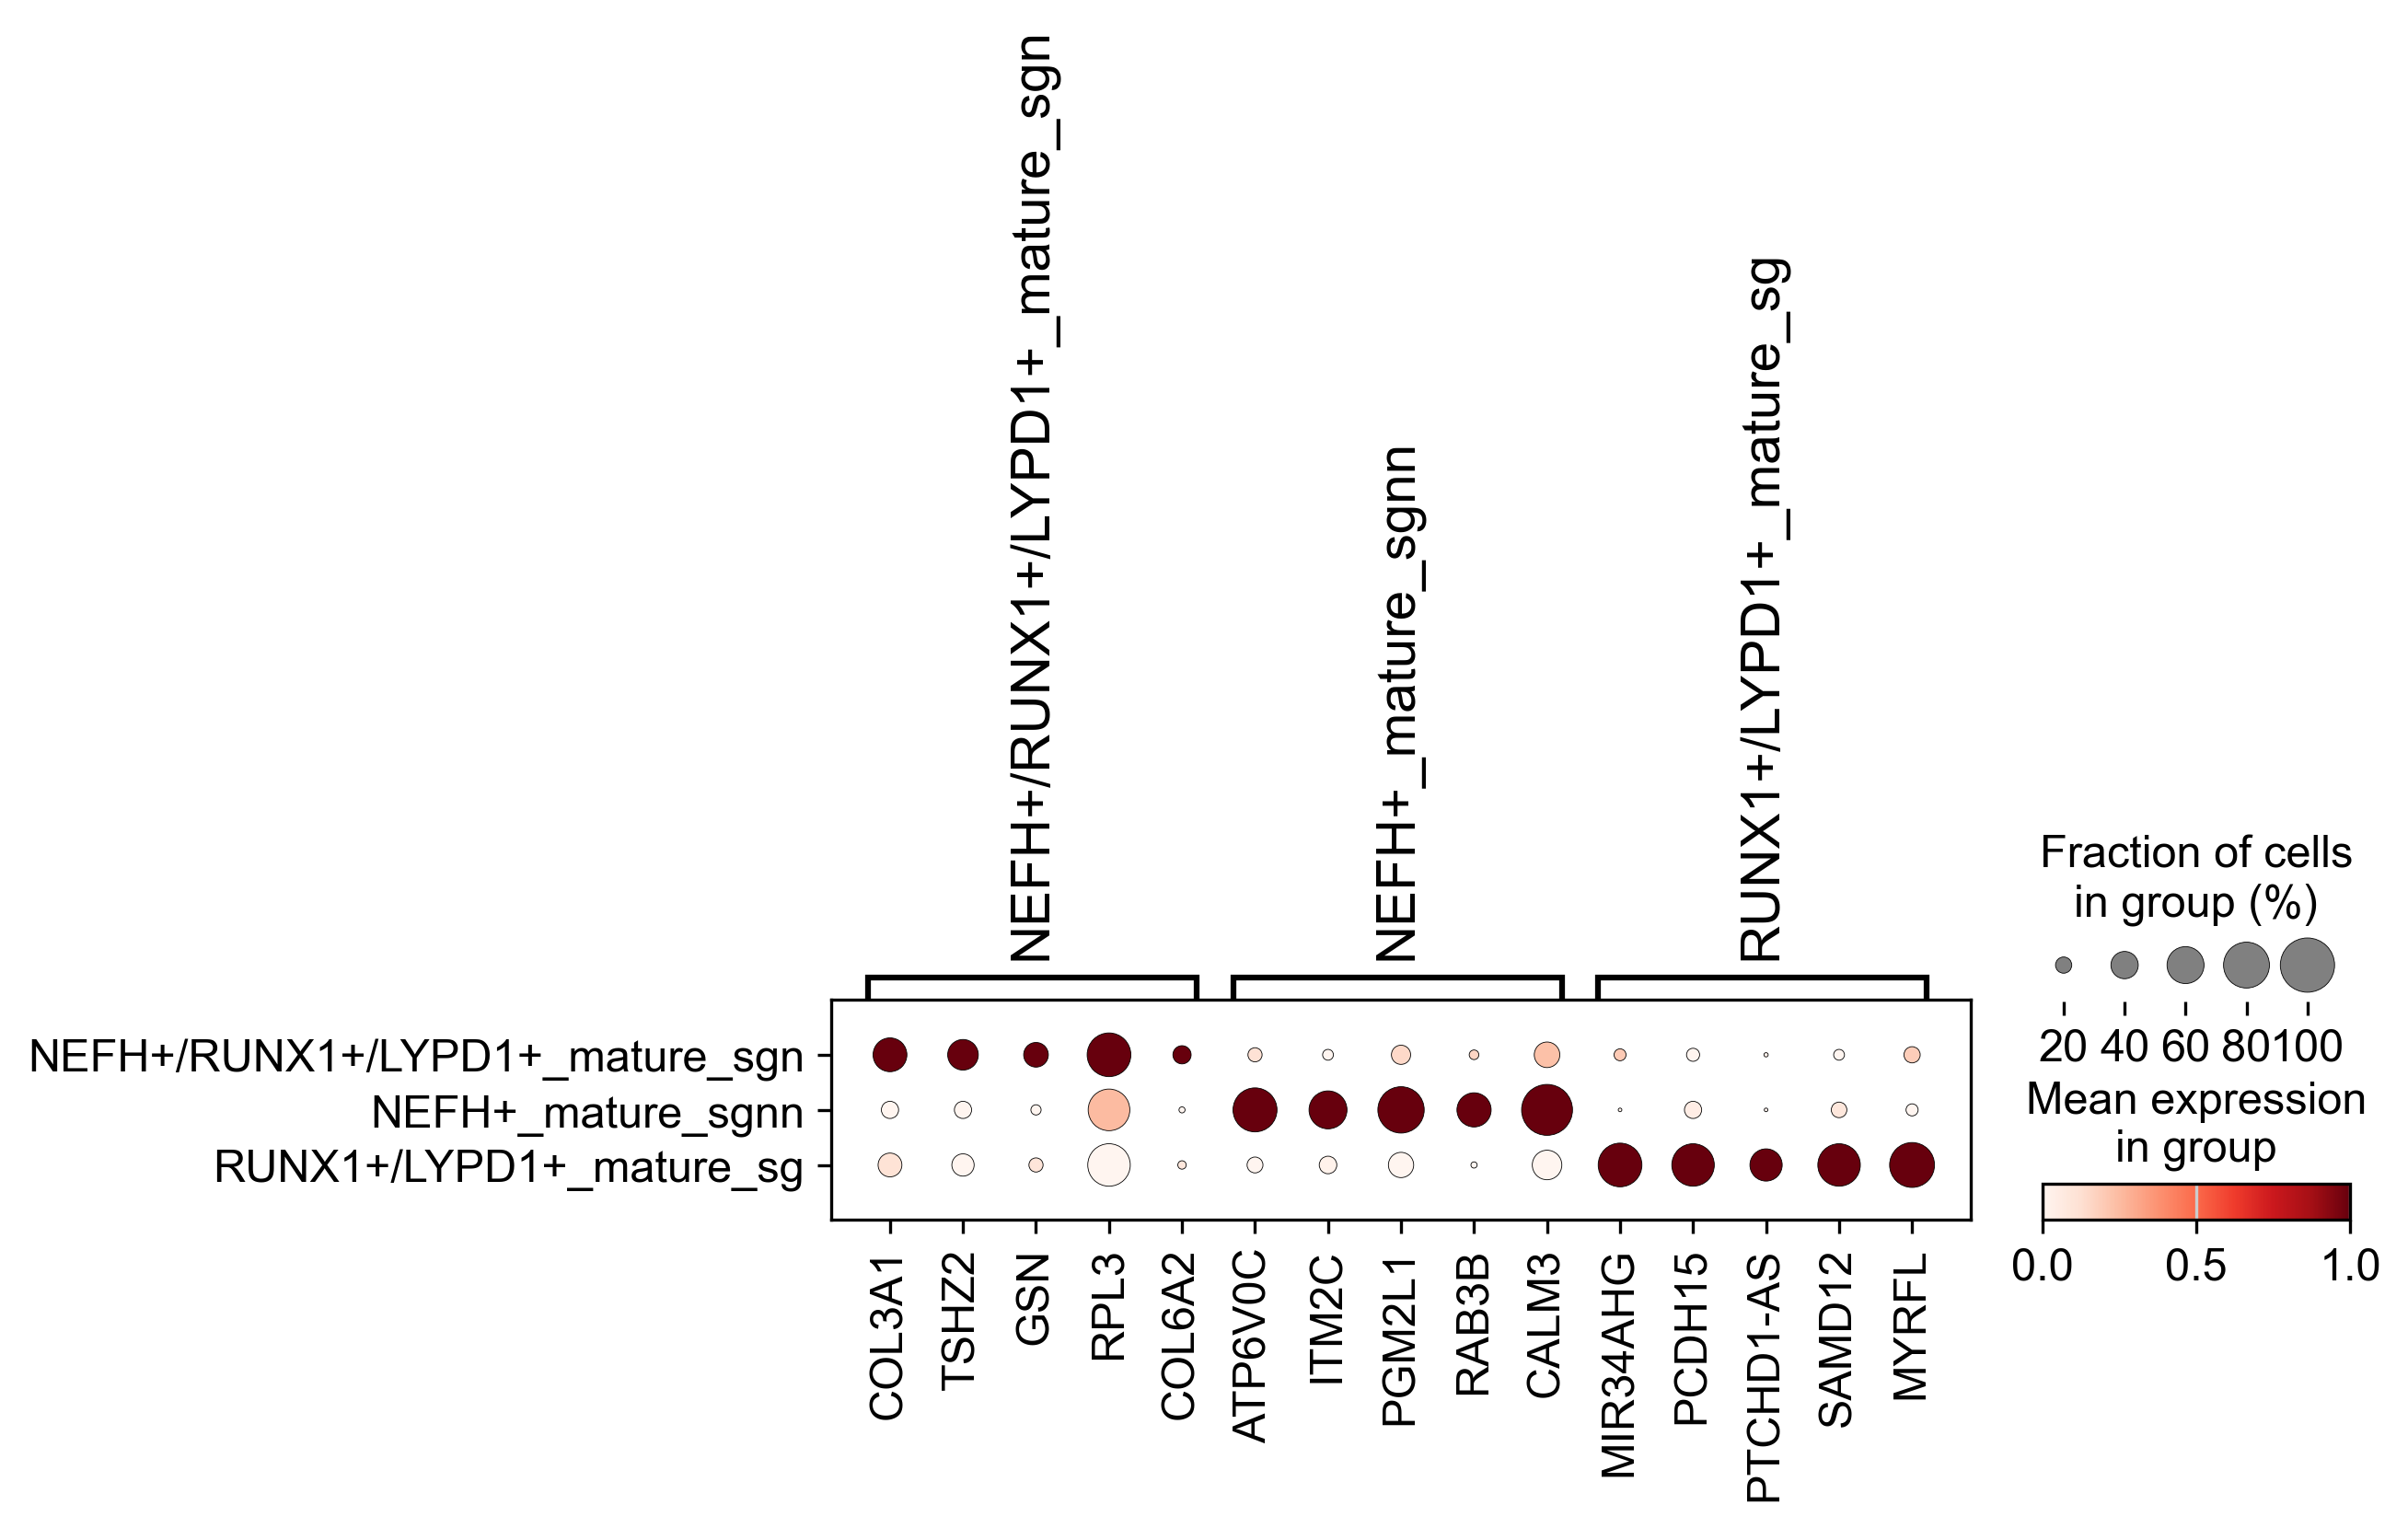

In [110]:
mks_final = filter_marker_stats(mkst_final, max_next_frac=0.1, min_mean_diff=0.05, how='or')
plot_markers(adata_positive_final_sgn_hm, 'cell_type_final', mks_final, standard_scale='var', save='dotplot_final_sgn_top5.pdf')

In [111]:
pd.DataFrame(mks_final).to_csv('human_final_sgn_markers2.csv')

In [119]:
cluster_annotation = {
 'NEFH+/RUNX1+/LYPD1+_mature_sgn': 'NEFH+_RUNX1+_LYPD1+_mature_sgn',
     'NEFH+_mature_sgnn': 'NEFH+_mature_sgn',
     'RUNX1+/LYPD1+_mature_sg': 'RUNX1+_LYPD1+_mature_sgn',
          

}
adata_positive_final_sgn_hm.obs['cell_type_final2'] = adata_positive_final_sgn_hm.obs['cell_type_final'].map(cluster_annotation).astype('category')

In [120]:
sc.tl.rank_genes_groups(adata_positive_final_sgn_hm, 'cell_type_final2',method='t-test',corr_method='benjamini-hochberg')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [121]:
import collections

In [129]:
# keep marker gene list
with pd.ExcelWriter('human_final_sgn_marker_ttest.xlsx') as writer:
    for cell_type_name in list(collections.Counter(adata_positive_final_sgn_hm.obs['cell_type_final2'])):
        celltype_list = []
        gene_list = list(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['names'])[cell_type_name][np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        score_list = list(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['scores'])[cell_type_name][np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        logfc_list = list(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name][np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        pvals_list = list(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name][np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        padj_list = list(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals_adj'])[cell_type_name][np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_final_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        celltype_list = [cell_type_name]*len(gene_list)
        #result_df = pd.DataFrame({'Celltype':celltype_list,'Gene':gene_list,'Scores':score_list,'Logfoldchanges':logfc_list,'Pvals':pvals_list,'Pvals_adj':padj_list})
        result_df = pd.DataFrame({'Gene':gene_list,'Pvals':pvals_list,'Pvals_adj':padj_list,'Logfoldchanges':logfc_list})
        filename = cell_type_name
        result_df.to_excel(writer,sheet_name=filename,index=False)

In [134]:
sc.tl.rank_genes_groups(adata_positive_gradual_sgn_hm, 'cell_type_final',method='t-test',corr_method='benjamini-hochberg')

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


In [135]:
# keep marker gene list
with pd.ExcelWriter('human_gradual_sgn_marker_ttest.xlsx') as writer:
    for cell_type_name in list(collections.Counter(adata_positive_gradual_sgn_hm.obs['cell_type_final'])):
        celltype_list = []
        gene_list = list(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['names'])[cell_type_name][np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        score_list = list(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['scores'])[cell_type_name][np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        logfc_list = list(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name][np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        pvals_list = list(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name][np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        padj_list = list(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals_adj'])[cell_type_name][np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['pvals'])[cell_type_name]<0.1)*np.array(pd.DataFrame(adata_positive_gradual_sgn_hm.uns['rank_genes_groups']['logfoldchanges'])[cell_type_name]>0)])
        celltype_list = [cell_type_name]*len(gene_list)
        #result_df = pd.DataFrame({'Celltype':celltype_list,'Gene':gene_list,'Scores':score_list,'Logfoldchanges':logfc_list,'Pvals':pvals_list,'Pvals_adj':padj_list})
        result_df = pd.DataFrame({'Gene':gene_list,'Pvals':pvals_list,'Pvals_adj':padj_list,'Logfoldchanges':logfc_list})
        filename = cell_type_name
        result_df.to_excel(writer,sheet_name=filename,index=False)